**🎯 Objectif du TP**

Construire un modèle LSTM capable de prédire le type de temps (**weather**) (ex. “rain”, “sun”, “snow”, etc.)
à partir des variables : date, precipitation, temp_max, temp_min, wind.

**A. LSTM**

**1. Importation des bibliothèques**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout, RepeatVector, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
plt.style.use('fivethirtyeight')

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


**2. Chargement du dataset**

In [2]:
df = pd.read_csv("/kaggle/input/weather-prediction/seattle-weather.csv")
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


**3. Exploration initiale du Dataset**

In [3]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())
df.describe()

(1461, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB
None
date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64
0


,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


**4. Préparation**

**a. Conversion de la date**

In [4]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df.drop(columns=['date'], inplace=True)

**b. Encodage de la variable cible (weather)**

In [5]:
df.head()

,precipitation,temp_max,temp_min,wind,weather,year,month,day
0,0.0,12.8,5.0,4.7,drizzle,2012,1,1
1,10.9,10.6,2.8,4.5,rain,2012,1,2
2,0.8,11.7,7.2,2.3,rain,2012,1,3
3,20.3,12.2,5.6,4.7,rain,2012,1,4
4,1.3,8.9,2.8,6.1,rain,2012,1,5


In [6]:
le = LabelEncoder()
df['weather'] = le.fit_transform(df['weather'])
df['weather'].value_counts()

weather
2    641
4    640
1    101
0     53
3     26
Name: count, dtype: int64

In [7]:
#Classes
le.classes_

array(['drizzle', 'fog', 'rain', 'snow', 'sun'], dtype=object)

**5. Préparation des données pour le LSTM**

Vue que le LSTM attend des séquences temporelles en entrée alors il faut structurer les données correctement.

**a. Définir les variables d’entrée et la sortie**

In [8]:
X = df[['precipitation', 'temp_max', 'temp_min', 'wind', 'year', 'month', 'day']].values
y = df['weather'].values

**b. Normalisation des features**

In [9]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

**c. Découpage train / test**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

**d. Mise en forme pour LSTM**

Un LSTM attend une entrée 3D : (samples, timesteps, features).
Ici, chaque observation correspond à 1 timestep.

In [11]:
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

**e. Encodage one-hot de la cible**

In [12]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

**6. Création du modèle LSTM**

In [13]:
# Nombre de classes (à partir du y_train encodé)
num_classes = y_train.shape[1]

# Définition du modèle LSTM empilé
model_LSTM = Sequential()

# 1ère couche LSTM + Dropout
model_LSTM.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))

model_LSTM.add(Dropout(0.2))

# 2ème couche LSTM + Dropout
model_LSTM.add(LSTM(units=50, return_sequences=True))
model_LSTM.add(Dropout(0.2))

# 3ème couche LSTM + Dropout
model_LSTM.add(LSTM(units=50, return_sequences=True))
model_LSTM.add(Dropout(0.2))

# 4ème couche LSTM + Dropout
model_LSTM.add(LSTM(units=50))
model_LSTM.add(Dropout(0.2))

# Couche de sortie — classification multiclasse
model_LSTM.add(Dense(units=num_classes, activation='softmax'))



**7. Compilation du modèle LSTM**

In [14]:
model_LSTM.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_LSTM.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 1, 50)             11600     
                                                                 
 dropout (Dropout)           (None, 1, 50)             0         
                                                                 
 lstm_1 (LSTM)               (None, 1, 50)             20200     
                                                                 
 dropout_1 (Dropout)         (None, 1, 50)             0         
                                                                 
 lstm_2 (LSTM)               (None, 1, 50)             20200     
                                                                 
 dropout_2 (Dropout)         (None, 1, 50)             0         
                                                                 
 lstm_3 (LSTM)               (None, 50)                2

**8. Entraînement du LSTM**

In [15]:
history_LSTM = model_LSTM.fit(
    X_train, y_train,
    epochs=500,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/500
30/30 [==============================] - 9s 50ms/step - loss: 1.5751 - accuracy: 0.4304 - val_loss: 1.5111 - val_accuracy: 0.4615
Epoch 2/500
30/30 [==============================] - 0s 9ms/step - loss: 1.3240 - accuracy: 0.4411 - val_loss: 1.0851 - val_accuracy: 0.4615
Epoch 3/500
30/30 [==============================] - 0s 9ms/step - loss: 1.1073 - accuracy: 0.4283 - val_loss: 1.0865 - val_accuracy: 0.4615
Epoch 4/500
30/30 [==============================] - 0s 9ms/step - loss: 1.0848 - accuracy: 0.4475 - val_loss: 1.0917 - val_accuracy: 0.4359
Epoch 5/500
30/30 [==============================] - 0s 9ms/step - loss: 1.0920 - accuracy: 0.4101 - val_loss: 1.0935 - val_accuracy: 0.4615
Epoch 6/500
30/30 [==============================] - 0s 9ms/step - loss: 1.0820 - accuracy: 0.4390 - val_loss: 1.0940 - val_accuracy: 0.4829
Epoch 7/500
30/30 [==============================] - 0s 9ms/step - loss: 1.0873 - accuracy: 0.4101 - val_loss: 1.0937 - val_accuracy: 0.4744
Epoch 8/500


**9. Évaluation du LSTM**

In [16]:
loss, acc = model_LSTM.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")

10/10 [==============================] - 0s 4ms/step - loss: 0.4997 - accuracy: 0.8396
Test Accuracy: 83.96%


**10. Visualisation des performances du LSTM**

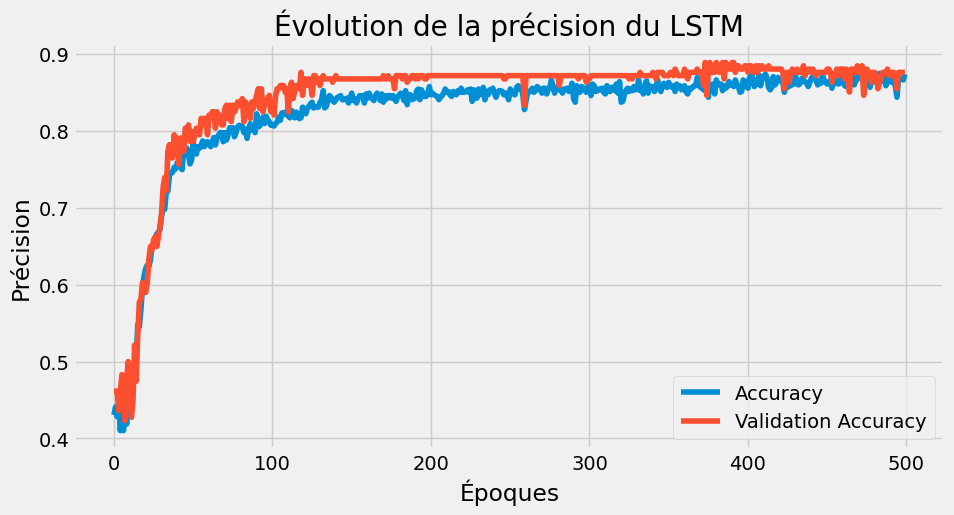

In [17]:
plt.figure(figsize=(10,5))
plt.plot(history_LSTM.history['accuracy'], label='Accuracy')
plt.plot(history_LSTM.history['val_accuracy'], label='Validation Accuracy')
plt.title("Évolution de la précision du LSTM")
plt.xlabel("Époques")
plt.ylabel("Précision")
plt.legend()
plt.show()


**11. Prédiction sur de nouvelles données du LSTM**

In [18]:
sample = np.array([[0.2, 18.0, 10.0, 3.5, 2024, 5, 12]])  # precipitation, temp_max, temp_min, wind, year, month, day
sample_scaled = scaler.transform(sample)
sample_scaled = sample_scaled.reshape((1, 1, sample_scaled.shape[1]))

prediction = model_LSTM.predict(sample_scaled)
pred_class = np.argmax(prediction)
print("Prévision :", le.inverse_transform([pred_class])[0])


1/1 [==============================] - 1s 1s/step
Prévision : rain


**12. Sauvegarde du modèle LSTM**

In [19]:
model_LSTM.save("weather_lstm_model.h5")

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


**B. GRU**

**1. Création du modèle GRU**

In [20]:
# The GRU architecture
model_GRU = Sequential()
# First GRU layer with Dropout regularisation
model_GRU.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]), activation='tanh'))

model_GRU.add(Dropout(0.2))
# Second GRU layer
model_GRU.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1],1), activation='tanh'))
model_GRU.add(Dropout(0.2))
# Third GRU layer
model_GRU.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1],1), activation='tanh'))
model_GRU.add(Dropout(0.2))
# Fourth GRU layer
model_GRU.add(GRU(units=50, activation='tanh'))
model_GRU.add(Dropout(0.2))
# The output layer
model_GRU.add(Dense(units=num_classes, activation='softmax'))

**2. Compilation du GRU**

In [21]:
model_GRU.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_GRU.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 1, 50)             8850      
                                                                 
 dropout_4 (Dropout)         (None, 1, 50)             0         
                                                                 
 gru_1 (GRU)                 (None, 1, 50)             15300     
                                                                 
 dropout_5 (Dropout)         (None, 1, 50)             0         
                                                                 
 gru_2 (GRU)                 (None, 1, 50)             15300     
                                                                 
 dropout_6 (Dropout)         (None, 1, 50)             0         
                                                                 
 gru_3 (GRU)                 (None, 50)               

**3. Entrainement du GRU**

In [22]:
history_GRU = model_GRU.fit(
    X_train, y_train,
    epochs=500,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/500
30/30 [==============================] - 7s 43ms/step - loss: 1.4524 - accuracy: 0.4272 - val_loss: 1.1560 - val_accuracy: 0.4188
Epoch 2/500
30/30 [==============================] - 0s 8ms/step - loss: 1.1010 - accuracy: 0.4368 - val_loss: 1.0977 - val_accuracy: 0.5513
Epoch 3/500
30/30 [==============================] - 0s 8ms/step - loss: 1.0944 - accuracy: 0.4486 - val_loss: 1.1094 - val_accuracy: 0.4188
Epoch 4/500
30/30 [==============================] - 0s 8ms/step - loss: 1.0745 - accuracy: 0.4636 - val_loss: 1.0898 - val_accuracy: 0.5085
Epoch 5/500
30/30 [==============================] - 0s 8ms/step - loss: 1.0708 - accuracy: 0.4872 - val_loss: 1.0954 - val_accuracy: 0.4402
Epoch 6/500
30/30 [==============================] - 0s 8ms/step - loss: 1.0649 - accuracy: 0.4989 - val_loss: 1.0643 - val_accuracy: 0.5940
Epoch 7/500
30/30 [==============================] - 0s 8ms/step - loss: 1.0218 - accuracy: 0.5696 - val_loss: 1.0043 - val_accuracy: 0.6111
Epoch 8/500


**4. Evaluation du GRU**

In [23]:
loss, acc = model_GRU.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")

10/10 [==============================] - 0s 4ms/step - loss: 0.5079 - accuracy: 0.8532
Test Accuracy: 85.32%


**5. Visualisation des performances du GRU**

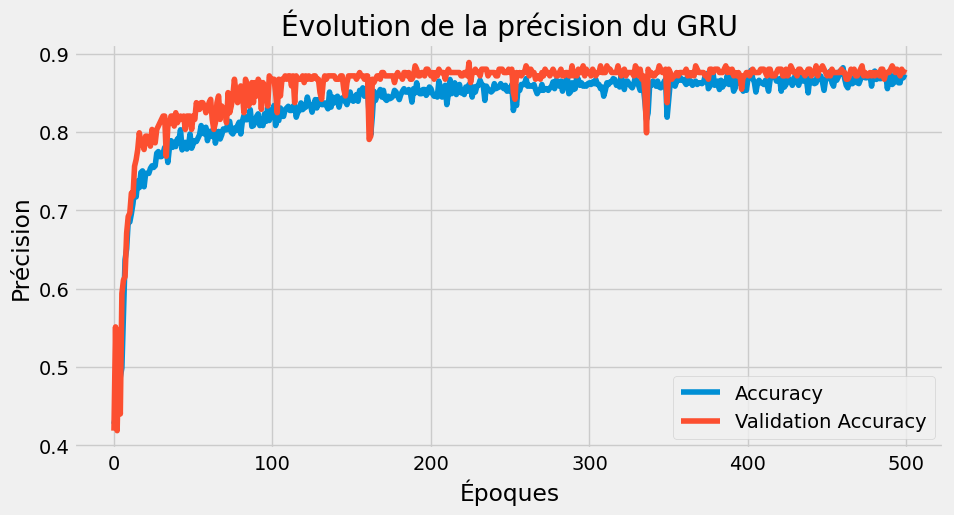

In [24]:
plt.figure(figsize=(10,5))
plt.plot(history_GRU.history['accuracy'], label='Accuracy')
plt.plot(history_GRU.history['val_accuracy'], label='Validation Accuracy')
plt.title("Évolution de la précision du GRU")
plt.xlabel("Époques")
plt.ylabel("Précision")
plt.legend()
plt.show()


**6. Test du GRU**

In [25]:
sample = np.array([[0.2, 18.0, 10.0, 3.5, 2024, 5, 12]])  # precipitation, temp_max, temp_min, wind, year, month, day
sample_scaled = scaler.transform(sample)
sample_scaled = sample_scaled.reshape((1, 1, sample_scaled.shape[1]))

prediction = model_GRU.predict(sample_scaled)
pred_class = np.argmax(prediction)
print("Prévision :", le.inverse_transform([pred_class])[0])

1/1 [==============================] - 1s 945ms/step
Prévision : rain


**7. Sauvegarde du GRU**

In [26]:
model_GRU.save("weather_gru_model.h5")

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


**C. GRU Encoder-Decoder**

**1. Creation du modèle**

In [27]:
num_classes = y_train.shape[1]
timesteps = X_train.shape[1]
features = X_train.shape[2]

# ===== ENCODER =====
encoder_inputs = Input(shape=(timesteps, features))
encoder_gru = GRU(100, return_state=True, dropout=0.2)
encoder_outputs, state_h = encoder_gru(encoder_inputs)

# ===== DECODER =====
decoder_inputs = RepeatVector(timesteps)(encoder_outputs)
decoder_gru = GRU(100, return_sequences=True, dropout=0.2)
decoder_outputs = decoder_gru(decoder_inputs, initial_state=[state_h])

decoder_dense = TimeDistributed(Dense(100, activation='relu'))(decoder_outputs)
decoder_final = Dense(num_classes, activation='softmax')(decoder_dense[:, -1, :])

model_RNN_EncDec_GRU = Model(encoder_inputs, decoder_final)


**2. Compilation**

In [28]:
model_RNN_EncDec_GRU.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Résumé
model_RNN_EncDec_GRU.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 1, 7)]               0         []                            
                                                                                                  
 gru_4 (GRU)                 [(None, 100),                32700     ['input_1[0][0]']             
                              (None, 100)]                                                        
                                                                                                  
 repeat_vector (RepeatVecto  (None, 1, 100)               0         ['gru_4[0][0]']               
 r)                                                                                               
                                                                                              

**3. Entrainement du GRU_Enc-Dec**

In [29]:
history_RNN_EncDec = model_RNN_EncDec_GRU.fit(
    X_train, y_train,
    epochs=500,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/500
30/30 [==============================] - 4s 27ms/step - loss: 1.3141 - accuracy: 0.4625 - val_loss: 1.0715 - val_accuracy: 0.4701
Epoch 2/500
30/30 [==============================] - 0s 6ms/step - loss: 1.0653 - accuracy: 0.5064 - val_loss: 1.0600 - val_accuracy: 0.4615
Epoch 3/500
30/30 [==============================] - 0s 7ms/step - loss: 1.0229 - accuracy: 0.5814 - val_loss: 0.9989 - val_accuracy: 0.6368
Epoch 4/500
30/30 [==============================] - 0s 7ms/step - loss: 0.9739 - accuracy: 0.6103 - val_loss: 0.9683 - val_accuracy: 0.6154
Epoch 5/500
30/30 [==============================] - 0s 7ms/step - loss: 0.9289 - accuracy: 0.6146 - val_loss: 0.9358 - val_accuracy: 0.6453
Epoch 6/500
30/30 [==============================] - 0s 6ms/step - loss: 0.9416 - accuracy: 0.6092 - val_loss: 0.8975 - val_accuracy: 0.6752
Epoch 7/500
30/30 [==============================] - 0s 6ms/step - loss: 0.8983 - accuracy: 0.6221 - val_loss: 0.8588 - val_accuracy: 0.6752
Epoch 8/500


**4. Evaluation**

In [30]:
loss, acc = model_RNN_EncDec_GRU.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")

10/10 [==============================] - 0s 3ms/step - loss: 0.5125 - accuracy: 0.8020
Test Accuracy: 80.20%


**5.Visualisation**

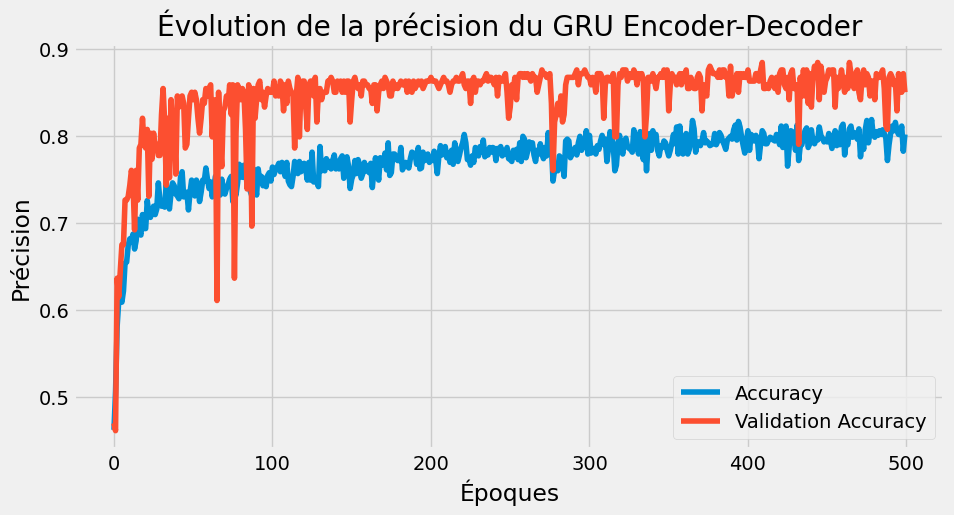

In [31]:
plt.figure(figsize=(10,5))
plt.plot(history_RNN_EncDec.history['accuracy'], label='Accuracy')
plt.plot(history_RNN_EncDec.history['val_accuracy'], label='Validation Accuracy')
plt.title("Évolution de la précision du GRU Encoder-Decoder")
plt.xlabel("Époques")
plt.ylabel("Précision")
plt.legend()
plt.show()

**6. Test GRU Encoder-Decoder**

In [32]:
sample = np.array([[0.2, 18.0, 10.0, 3.5, 2024, 5, 12]])  # precipitation, temp_max, temp_min, wind, year, month, day
sample_scaled = scaler.transform(sample)
sample_scaled = sample_scaled.reshape((1, 1, sample_scaled.shape[1]))

prediction = model_RNN_EncDec_GRU.predict(sample_scaled)
pred_class = np.argmax(prediction)
print("Prévision :", le.inverse_transform([pred_class])[0])

1/1 [==============================] - 1s 504ms/step
Prévision : sun


**7. Sauvegarde**

In [33]:
model_GRU.save("weather_GRU_EncDec_model.h5")

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
